In [1]:
!pip install pycaret

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 486.1/486.1 kB 9.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.8/106.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.8/21.8 MB 57.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.2/302.2 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 56.9 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.6/200.6 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 75.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━

In [6]:
import pandas as pd
from pycaret.classification import *
import os

# Load the dataset
file_path = '/kaggle/input/new2yjg/accidents_data.csv'
data = pd.read_csv(file_path, encoding='latin1')

# Data Preprocessing
data.columns = data.columns.str.strip()  # Strip leading and trailing spaces from column names
data.replace('-', pd.NA, inplace=True)  # Replace placeholder '-' with NaN
data.fillna('Unknown', inplace=True)  # Fill NaN values with 'Unknown'

# Remove classes with less than 2 samples in the target column
class_counts = data['Cause of accident'].value_counts()
valid_classes = class_counts[class_counts >= 2].index
data = data[data['Cause of accident'].isin(valid_classes)]

# Set up PyCaret for classification
clf_setup = setup(
    data=data,
    target='Cause of accident',
    session_id=42,
    log_experiment=False
)

# Train and compare models
print("Comparing models...")
best_model = compare_models(sort='Accuracy')  # Choose the best model based on Accuracy (or any other metric)

# Create the best model explicitly
print(f"Training the best model: {best_model}")
best_model = create_model(best_model)

# Save evaluation plots for the best model
output_dir = '/kaggle/working/xyz'  # Save to 'xyz' directory in Kaggle environment
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Generate and save other evaluation plots
plot_names = ['auc', 'pr', 'feature', 'confusion_matrix', 'class_report', 'learning']
for plot_name in plot_names:
    plot_file_path = os.path.join(output_dir, f"{plot_name}_{str(best_model).split('(')[0].lower()}.png")
    try:
        # Generate and save plots
        plot_model(best_model, plot=plot_name, save=True)
        saved_file = [f for f in os.listdir() if plot_name in f and f.endswith('.png')]
        if saved_file:
            os.rename(saved_file[0], plot_file_path)
        print(f"{plot_name.capitalize()} plot saved at '{plot_file_path}'")
    except Exception as e:
        print(f"Plot '{plot_name}' could not be generated: {e}")

# Save the best model for future use
model_name = str(best_model).split('(')[0].lower()  # Use the model name for saving
save_model(best_model, os.path.join(output_dir, f'{model_name}_cause_of_accident_model'))

print(f"Model training complete. All plots and the best model are saved in the folder '{output_dir}'.")


,Description,Value
0,Session id,42
1,Target,Cause of accident
2,Target type,Multiclass
3,Target mapping,"Overspeed: 0, Overtaking: 1, Recklessly Driving: 2"
4,Original data shape,"(112, 9)"
5,Transformed data shape,"(112, 29)"
6,Transformed train set shape,"(78, 29)"
7,Transformed test set shape,"(34, 29)"
8,Numeric features,4
9,Categorical features,4


Comparing models...


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.7107,0.0000,0.7107,0.6406,0.6594,0.4443,0.4947,0.0910
ridge,Ridge Classifier,0.7089,0.0000,0.7089,0.6282,0.6531,0.4372,0.4890,0.0610
et,Extra Trees Classifier,0.6821,0.8062,0.6821,0.5992,0.6194,0.3915,0.4340,0.1480
rf,Random Forest Classifier,0.6429,0.8151,0.6429,0.5479,0.5724,0.2952,0.3340,0.1660
qda,Quadratic Discriminant Analysis,0.6429,0.0000,0.6429,0.4609,0.5235,0.1814,0.2349,0.0640
gbc,Gradient Boosting Classifier,0.6429,0.0000,0.6429,0.5846,0.5989,0.3587,0.3988,0.2070
lda,Linear Discriminant Analysis,0.6250,0.0000,0.6250,0.5535,0.5658,0.3219,0.3707,0.0650
ada,Ada Boost Classifier,0.6018,0.0000,0.6018,0.5102,0.5272,0.2174,0.2743,0.1090
lightgbm,Light Gradient Boosting Machine,0.5804,0.7432,0.5804,0.5642,0.5377,0.2683,0.3149,6.0520
dummy,Dummy Classifier,0.5804,0.5000,0.5804,0.3442,0.4299,0.0000,0.0000,0.0710


Training the best model: LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=42, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6250,0.0000,0.6250,0.5833,0.6000,0.4000,0.4104
1,0.8750,0.0000,0.8750,0.9000,0.8611,0.7895,0.8135
2,0.6250,0.0000,0.6250,0.5357,0.5303,0.2941,0.4226
3,0.5000,0.0000,0.5000,0.4583,0.4750,0.2000,0.2052
4,0.6250,0.0000,0.6250,0.5357,0.5303,0.2941,0.4226
5,0.6250,0.0000,0.6250,0.5417,0.5795,0.2258,0.2354
6,0.6250,0.0000,0.6250,0.5417,0.5795,0.2000,0.2100
7,0.7500,0.0000,0.7500,0.5714,0.6458,0.4286,0.5500
8,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000


...

Pr plot saved at '/kaggle/working/xyz/pr_logisticregression.png'


Feature plot saved at '/kaggle/working/xyz/feature_logisticregression.png'


Confusion_matrix plot saved at '/kaggle/working/xyz/confusion_matrix_logisticregression.png'


Class_report plot saved at '/kaggle/working/xyz/class_report_logisticregression.png'


Learning plot saved at '/kaggle/working/xyz/learning_logisticregression.png'
Transformation Pipeline and Model Successfully Saved
Model training complete. All plots and the best model are saved in the folder '/kaggle/working/xyz'.


In [4]:
import pickle

# Path to the uploaded file
file_path = '/kaggle/working/xyz/logisticregression_cause_of_accident_model.pkl'

# Load the model from the file
with open(file_path, 'rb') as file:
    model = pickle.load(file)

# Output to show that the model has been loaded
type(model)


numpy.ndarray

In [5]:
import numpy as np

# Check the contents of the loaded model
model_content = np.array(model)

# Display the shape and the first few elements to understand its structure
model_content.shape, model_content[:5]  # Display the shape and first 5 elements for context


((3,), array(['Overspeed', 'Overtaking', 'Recklessly Driving'], dtype=object))

In [7]:
import pandas as pd
from pycaret.classification import *
import os

# Load the dataset
file_path = '/kaggle/input/new2yjg/accidents_data.csv'
data = pd.read_csv(file_path, encoding='latin1')

# Data Preprocessing
data.columns = data.columns.str.strip()  # Strip leading and trailing spaces from column names

# Replace special characters (e.g., spaces, commas, etc.) in column names
data.columns = data.columns.str.replace('[^A-Za-z0-9_]', '_', regex=True)

# Replace placeholder '-' with NaN
data.replace('-', pd.NA, inplace=True)

# Fill NaN values with 'Unknown'
data.fillna('Unknown', inplace=True)

# Drop the 'Serial No.' column
if 'Serial No.' in data.columns:
    data.drop(columns=['Serial No.'], inplace=True)

# Standardize the date format in 'Date of accident' column
if 'Date_of_accident' in data.columns:
    data['Date_of_accident'] = pd.to_datetime(data['Date_of_accident'], errors='coerce')

# Remove classes with less than 2 samples in the target column
# The column name after sanitization will be 'Cause_of_accident'
if 'Cause_of_accident' in data.columns:
    class_counts = data['Cause_of_accident'].value_counts()
    valid_classes = class_counts[class_counts >= 2].index
    data = data[data['Cause_of_accident'].isin(valid_classes)]
else:
    print("'Cause_of_accident' column not found in the data.")

# Set up PyCaret for classification
clf_setup = setup(
    data=data,
    target='Cause_of_accident',  # Ensure that the sanitized column name is used
    session_id=42,
    log_experiment=False
)

# Train and compare models
print("Comparing models...")
best_model = compare_models(sort='Accuracy')  # Choose the best model based on AUC (or any metric)

# Create the best model explicitly
print(f"Training the best model: {best_model}")
best_model = create_model(best_model)

# Save evaluation plots for the best model
output_dir = 'pycaret_plots'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Generate SHAP analysis for the best model
try:
    print("Performing SHAP analysis on the best model...")
    interpret_model(best_model, plot='summary')  # Display SHAP summary plot
    shap_output_path = os.path.join(output_dir, f'shap_summary_{str(best_model).split("(")[0].lower()}.png')
    interpret_model(best_model, plot='summary', save=True)  # Save SHAP summary plot
    saved_file = [f for f in os.listdir() if 'SHAP summary' in f and f.endswith('.png')]
    if saved_file:
        os.rename(saved_file[0], shap_output_path)
    print(f"SHAP summary plot for the best model saved at '{shap_output_path}'")
except Exception as e:
    print(f"SHAP analysis for the best model could not be performed: {e}")

# Generate and save other evaluation plots
plot_names = ['auc', 'pr', 'feature', 'confusion_matrix', 'class_report', 'learning']
for plot_name in plot_names:
    plot_file_path = os.path.join(output_dir, f"{plot_name}_{str(best_model).split('(')[0].lower()}.png")
    try:
        # Generate and save plots
        plot_model(best_model, plot=plot_name, save=True)
        saved_file = [f for f in os.listdir() if plot_name in f and f.endswith('.png')]
        if saved_file:
            os.rename(saved_file[0], plot_file_path)
        print(f"{plot_name.capitalize()} plot saved at '{plot_file_path}'")
    except Exception as e:
        print(f"Plot '{plot_name}' could not be generated: {e}")

# Save the best model for future use
model_name = str(best_model).split('(')[0].lower()  # Use the model name for saving
save_model(best_model, os.path.join(output_dir, f'{model_name}_cause_of_accident_model'))

print(f"Model training complete. SHAP analysis, all plots, and the best model are saved in the folder '{output_dir}'.")


,Description,Value
0,Session id,42
1,Target,Cause_of_accident
2,Target type,Multiclass
3,Target mapping,"Overspeed: 0, Overtaking: 1, Recklessly Driving: 2"
4,Original data shape,"(112, 9)"
5,Transformed data shape,"(112, 29)"
6,Transformed train set shape,"(78, 29)"
7,Transformed test set shape,"(34, 29)"
8,Numeric features,4
9,Categorical features,4


Comparing models...


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.7107,0.0000,0.7107,0.6406,0.6594,0.4443,0.4947,0.0980
ridge,Ridge Classifier,0.7089,0.0000,0.7089,0.6282,0.6531,0.4372,0.4890,0.0610
et,Extra Trees Classifier,0.6821,0.8062,0.6821,0.5992,0.6194,0.3915,0.4340,0.1470
rf,Random Forest Classifier,0.6429,0.8151,0.6429,0.5479,0.5724,0.2952,0.3340,0.1620
qda,Quadratic Discriminant Analysis,0.6429,0.0000,0.6429,0.4609,0.5235,0.1814,0.2349,0.0610
gbc,Gradient Boosting Classifier,0.6429,0.0000,0.6429,0.5846,0.5989,0.3587,0.3988,0.2050
lda,Linear Discriminant Analysis,0.6250,0.0000,0.6250,0.5535,0.5658,0.3219,0.3707,0.0600
ada,Ada Boost Classifier,0.6018,0.0000,0.6018,0.5102,0.5272,0.2174,0.2743,0.1070
lightgbm,Light Gradient Boosting Machine,0.5804,0.7432,0.5804,0.5642,0.5377,0.2683,0.3149,6.9400
dummy,Dummy Classifier,0.5804,0.5000,0.5804,0.3442,0.4299,0.0000,0.0000,0.0630


Training the best model: LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=42, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6250,0.0000,0.6250,0.5833,0.6000,0.4000,0.4104
1,0.8750,0.0000,0.8750,0.9000,0.8611,0.7895,0.8135
2,0.6250,0.0000,0.6250,0.5357,0.5303,0.2941,0.4226
3,0.5000,0.0000,0.5000,0.4583,0.4750,0.2000,0.2052
4,0.6250,0.0000,0.6250,0.5357,0.5303,0.2941,0.4226
5,0.6250,0.0000,0.6250,0.5417,0.5795,0.2258,0.2354
6,0.6250,0.0000,0.6250,0.5417,0.5795,0.2000,0.2100
7,0.7500,0.0000,0.7500,0.5714,0.6458,0.4286,0.5500
8,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000


...

Pr plot saved at 'pycaret_plots/pr_logisticregression.png'


Feature plot saved at 'pycaret_plots/feature_logisticregression.png'


Confusion_matrix plot saved at 'pycaret_plots/confusion_matrix_logisticregression.png'


Class_report plot saved at 'pycaret_plots/class_report_logisticregression.png'


Learning plot saved at 'pycaret_plots/learning_logisticregression.png'
Transformation Pipeline and Model Successfully Saved
Model training complete. SHAP analysis, all plots, and the best model are saved in the folder 'pycaret_plots'.


,Description,Value
0,Session id,42
1,Target,Cause_of_accident
2,Target type,Multiclass
3,Target mapping,"Overspeed: 0, Overtaking: 1, Recklessly Driving: 2"
4,Original data shape,"(112, 9)"
5,Transformed data shape,"(112, 29)"
6,Transformed train set shape,"(78, 29)"
7,Transformed test set shape,"(34, 29)"
8,Numeric features,4
9,Categorical features,4


Comparing models...


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.6429,0.8193,0.6429,0.5479,0.5724,0.2952,0.3340,0.1710
et,Extra Trees Classifier,0.6821,0.8062,0.6821,0.5992,0.6194,0.3915,0.4340,0.1580
catboost,CatBoost Classifier,0.5304,0.7783,0.5304,0.5452,0.5089,0.2210,0.2526,0.5700
xgboost,Extreme Gradient Boosting,0.5411,0.7388,0.5411,0.5740,0.5196,0.2366,0.2776,0.0990
lightgbm,Light Gradient Boosting Machine,0.5786,0.7205,0.5786,0.5798,0.5412,0.2813,0.3253,6.3690
dt,Decision Tree Classifier,0.5536,0.7102,0.5536,0.6149,0.5523,0.2819,0.3184,0.0700
nb,Naive Bayes,0.2536,0.6433,0.2536,0.3557,0.2247,0.0162,-0.0006,0.0700
knn,K Neighbors Classifier,0.6054,0.6323,0.6054,0.5477,0.5564,0.1989,0.2144,0.0800
dummy,Dummy Classifier,0.5804,0.5000,0.5804,0.3442,0.4299,0.0000,0.0000,0.0660
lr,Logistic Regression,0.6804,0.0000,0.6804,0.5983,0.6172,0.3915,0.4556,0.6700


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
qda,Quadratic Discriminant Analysis,0.6964,0.0000,0.6964,0.6128,0.6315,0.3932,0.4501,0.0860
ridge,Ridge Classifier,0.6929,0.0000,0.6929,0.5928,0.6254,0.4032,0.4588,0.0660
et,Extra Trees Classifier,0.6821,0.8062,0.6821,0.5992,0.6194,0.3915,0.4340,0.1430
lr,Logistic Regression,0.6804,0.0000,0.6804,0.5983,0.6172,0.3915,0.4556,0.0690
svm,SVM - Linear Kernel,0.6643,0.0000,0.6643,0.6044,0.6143,0.3707,0.4189,0.0690
rf,Random Forest Classifier,0.6429,0.8193,0.6429,0.5479,0.5724,0.2952,0.3340,0.1830
gbc,Gradient Boosting Classifier,0.6429,0.0000,0.6429,0.5846,0.5989,0.3587,0.3988,0.2090
lda,Linear Discriminant Analysis,0.6250,0.0000,0.6250,0.5535,0.5658,0.3219,0.3707,0.0660
knn,K Neighbors Classifier,0.6054,0.6323,0.6054,0.5477,0.5564,0.1989,0.2144,0.0670
ada,Ada Boost Classifier,0.6018,0.0000,0.6018,0.5102,0.5272,0.2174,0.2743,0.1110


Training the best model: RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='sqrt',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, n_estimators=100, n_jobs=-1,
                       oob_score=False, random_state=42, verbose=0,
                       warm_start=False)


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.5000,0.7188,0.5000,0.4583,0.4750,0.2000,0.2052
1,0.7500,0.9271,0.7500,0.8750,0.7619,0.6190,0.6669
2,0.6250,0.8854,0.6250,0.4583,0.5250,0.3333,0.3873
3,0.6250,0.8125,0.6250,0.4833,0.5444,0.3684,0.4041
4,0.6250,0.7240,0.6250,0.5357,0.5303,0.2941,0.4226
5,0.6250,0.8333,0.6250,0.3906,0.4808,0.0000,0.0000
6,0.6250,0.8036,0.6250,0.3906,0.4808,0.0000,0.0000
7,0.6250,0.7500,0.6250,0.5417,0.5625,0.3333,0.3757
8,0.5714,0.8333,0.5714,0.6071,0.5714,0.1923,0.2015


Training the second-best model: RidgeClassifier(alpha=1.0, class_weight=None, copy_X=True, fit_intercept=True,
                max_iter=None, positive=False, random_state=42, solver='auto',
                tol=0.0001)


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6250,0.0000,0.6250,0.5833,0.6000,0.4000,0.4104
1,0.8750,0.0000,0.8750,0.9000,0.8611,0.7895,0.8135
2,0.7500,0.0000,0.7500,0.5833,0.6500,0.5556,0.6455
3,0.6250,0.0000,0.6250,0.4833,0.5444,0.3684,0.4041
4,0.6250,0.0000,0.6250,0.5357,0.5303,0.2941,0.4226
5,0.7500,0.0000,0.7500,0.5714,0.6458,0.4286,0.5500
6,0.6250,0.0000,0.6250,0.4464,0.5208,0.1429,0.1833
7,0.6250,0.0000,0.6250,0.4792,0.5379,0.2500,0.2801
8,0.5714,0.0000,0.5714,0.6071,0.5714,0.1923,0.2015


Generating plots for the best model...


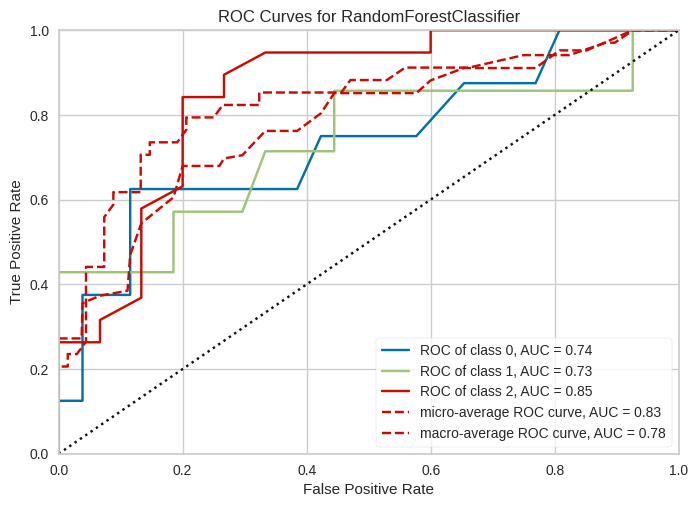

Auc plot displayed.


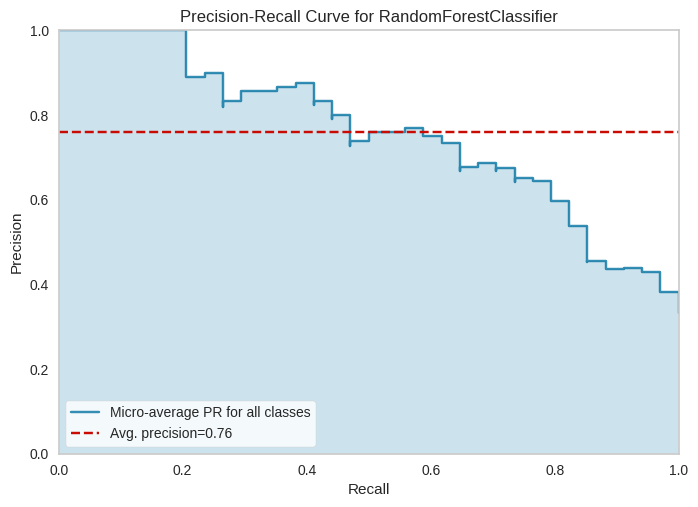

Pr plot displayed.


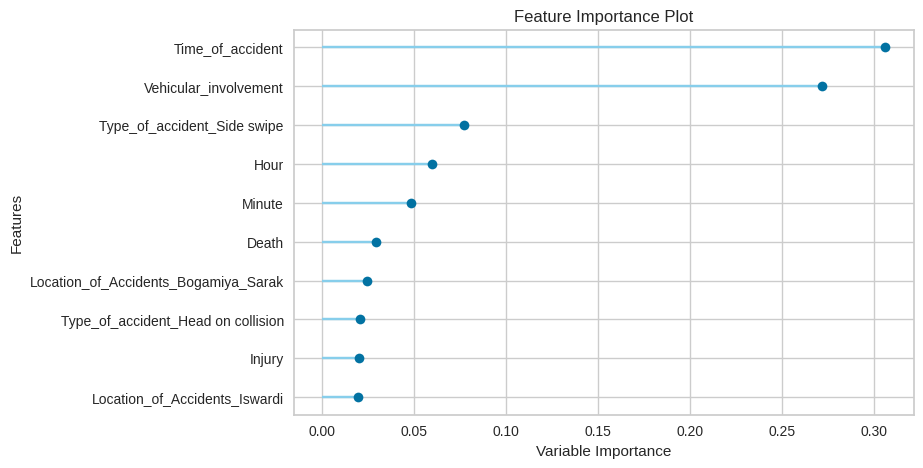

Feature plot displayed.


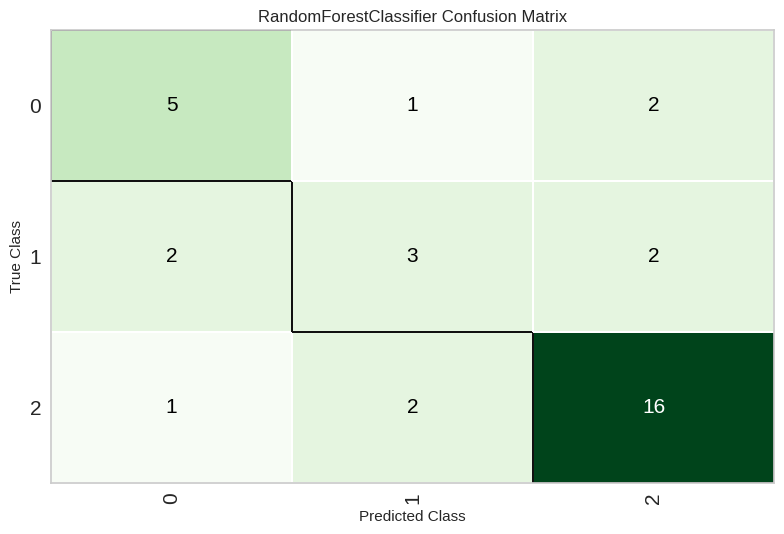

Confusion_matrix plot displayed.


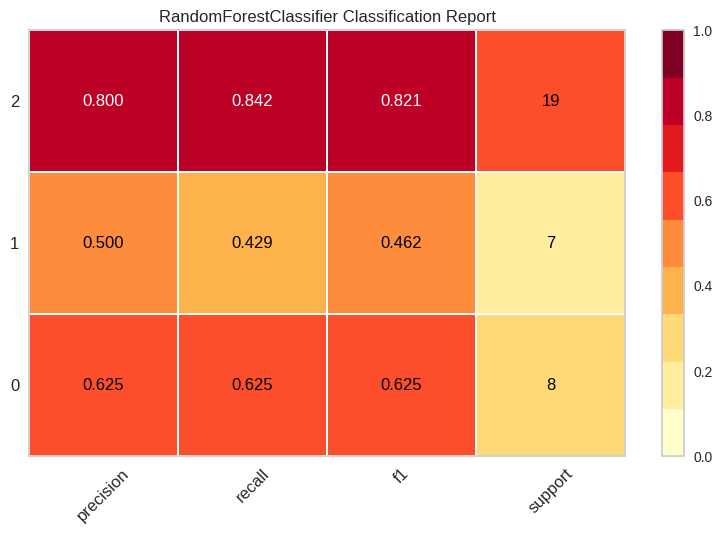

Class_report plot displayed.


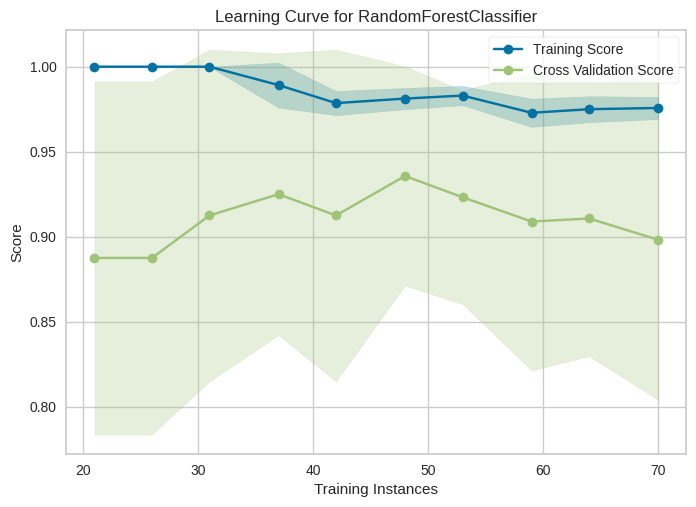

Learning plot displayed.
Generating plots for the second-best model...
Plot 'auc' for the second-best model could not be generated: AUC plot not available for estimators with no predict_proba attribute.


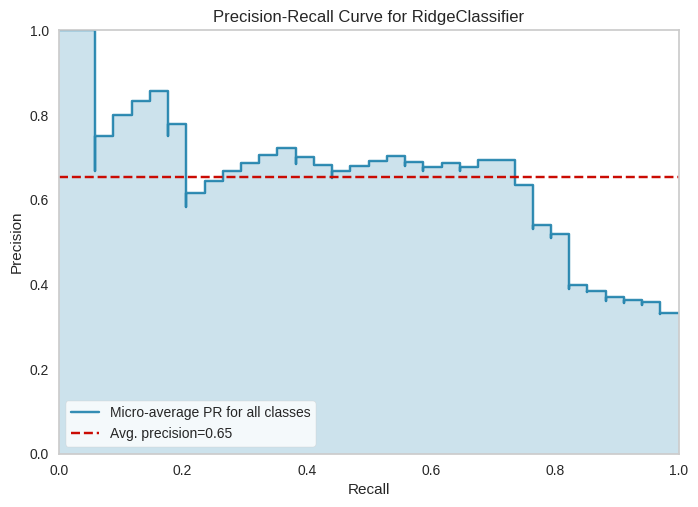

Pr plot for the second-best model displayed.


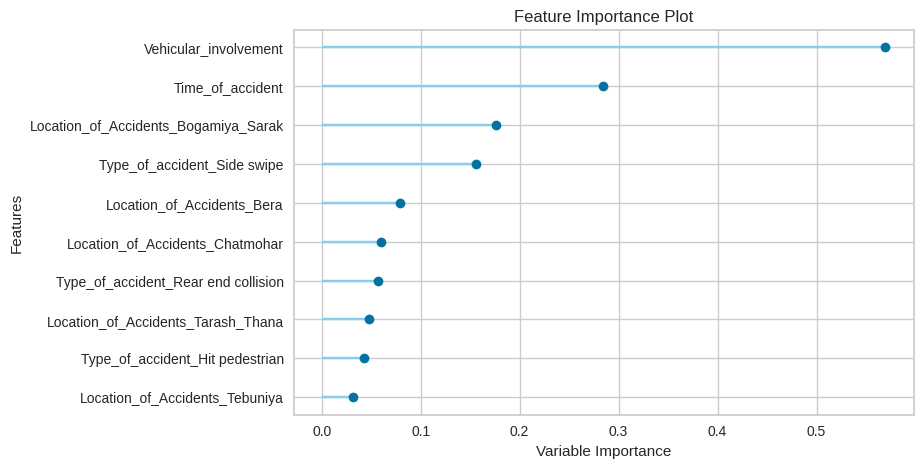

Feature plot for the second-best model displayed.


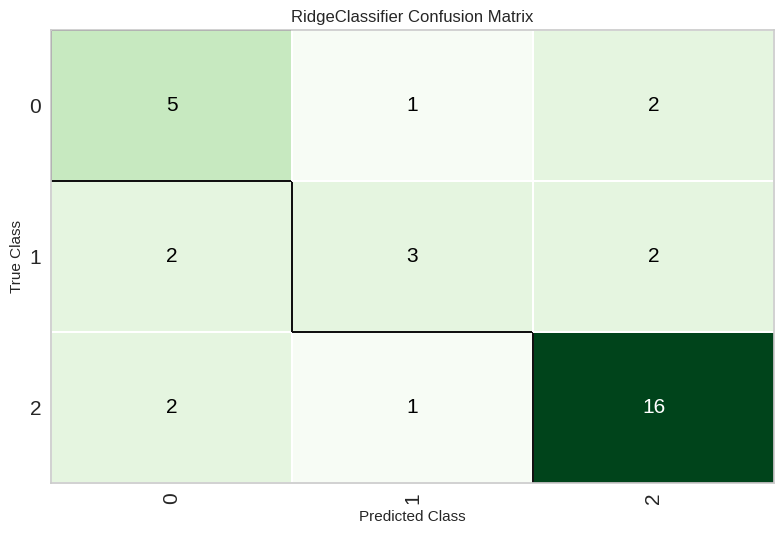

Confusion_matrix plot for the second-best model displayed.


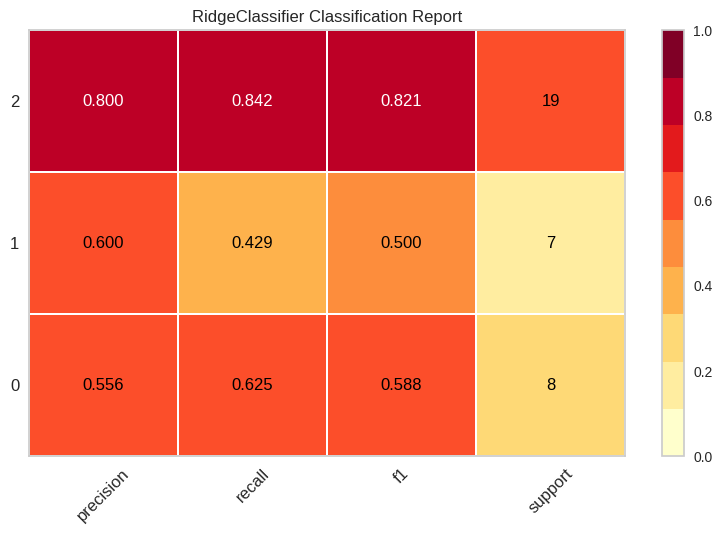

Class_report plot for the second-best model displayed.


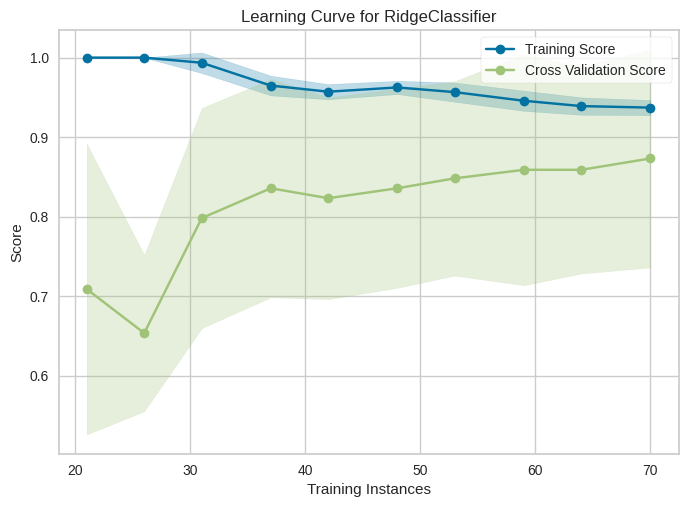

Learning plot for the second-best model displayed.


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from pycaret.classification import *
import os

# Load the dataset
file_path = '/kaggle/input/new2yjg/accidents_data.csv'
data = pd.read_csv(file_path, encoding='latin1')

# Data Preprocessing
data.columns = data.columns.str.strip()  # Strip leading and trailing spaces from column names

# Replace special characters (e.g., spaces, commas, etc.) in column names
data.columns = data.columns.str.replace('[^A-Za-z0-9_]', '_', regex=True)

# Replace placeholder '-' with NaN
data.replace('-', pd.NA, inplace=True)

# Fill NaN values with 'Unknown'
data.fillna('Unknown', inplace=True)

# Remove classes with less than 2 samples in the target column
if 'Cause_of_accident' in data.columns:
    class_counts = data['Cause_of_accident'].value_counts()
    valid_classes = class_counts[class_counts >= 2].index
    data = data[data['Cause_of_accident'].isin(valid_classes)]
else:
    print("'Cause_of_accident' column not found in the data.")

# Set up PyCaret for classification
clf_setup = setup(
    data=data,
    target='Cause_of_accident',  # Ensure that the sanitized column name is used
    session_id=42,
    fix_imbalance=False, 
    normalize=True
)

# Train and compare models
print("Comparing models...")
best_model = compare_models(sort='AUC')  # Choose the best model based on AUC (or any metric)

# Capture the second-best model
second_best_model = compare_models(sort='Accuracy', n_select=2)[1]

# Create the best model explicitly
print(f"Training the best model: {best_model}")
best_model = create_model(best_model)

# Create the second-best model explicitly
print(f"Training the second-best model: {second_best_model}")
second_best_model = create_model(second_best_model)

# List of plot types you want to generate for the best and second-best models
plot_names = ['auc', 'pr', 'feature', 'confusion_matrix', 'class_report', 'learning']

# For the best model
print("Generating plots for the best model...")
for plot_name in plot_names:
    try:
        plot_model(best_model, plot=plot_name)  # Just display the plot without saving
        plt.show()  # Display the plot
        print(f"{plot_name.capitalize()} plot displayed.")
    except Exception as e:
        print(f"Plot '{plot_name}' for the best model could not be generated: {e}")

# For the second-best model
print("Generating plots for the second-best model...")
for plot_name in plot_names:
    try:
        plot_model(second_best_model, plot=plot_name)  # Just display the plot without saving
        plt.show()  # Display the plot
        print(f"{plot_name.capitalize()} plot for the second-best model displayed.")
    except Exception as e:
        print(f"Plot '{plot_name}' for the second-best model could not be generated: {e}")


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pycaret.classification import *
import os

# Load the dataset
file_path = '/kaggle/input/new2yjg/accidents_data.csv'
data = pd.read_csv(file_path, encoding='latin1')

# Data Preprocessing
data.columns = data.columns.str.strip()  # Strip leading and trailing spaces from column names

# Replace special characters (e.g., spaces, commas, etc.) in column names
data.columns = data.columns.str.replace('[^A-Za-z0-9_]', '_', regex=True)

# Replace placeholder '-' with NaN
data.replace('-', pd.NA, inplace=True)

# Fill NaN values with 'Unknown'
data.fillna('Unknown', inplace=True)

# Remove classes with less than 2 samples in the target column
if 'Cause_of_accident' in data.columns:
    class_counts = data['Cause_of_accident'].value_counts()
    valid_classes = class_counts[class_counts >= 2].index
    data = data[data['Cause_of_accident'].isin(valid_classes)]
else:
    print("'Cause_of_accident' column not found in the data.")

# Set up PyCaret for classification
clf_setup = setup(
    data=data,
    target='Cause_of_accident',  # Ensure that the sanitized column name is used
    session_id=42,
    fix_imbalance=False,  # Fixing class imbalance
    normalize=False,
    # feature_selection=True,  # Automatic feature selection
    # transformation=True,  # Apply transformations to improve data distribution
    # cross_validation=True,  # Enable cross-validation to reduce overfitting
    fold=5,  # Using 5 folds for cross-validation
)

# Train and compare models
print("Comparing models...")
best_model = compare_models(sort='AUC')  # Choose the best model based on AUC (or any metric)

# Capture the second-best model
second_best_model = compare_models(sort='Accuracy', n_select=2)[1]

# Create the best model explicitly
print(f"Training the best model: {best_model}")
best_model = create_model(best_model)

# Create the second-best model explicitly
print(f"Training the second-best model: {second_best_model}")
second_best_model = create_model(second_best_model)

# Tune the best model to further reduce overfitting and improve accuracy
print(f"Tuning the best model: {best_model}")
best_model = tune_model(best_model)

# Tune the second-best model
print(f"Tuning the second-best model: {second_best_model}")
second_best_model = tune_model(second_best_model)

xgboost_model = create_model('xgboost')
lightgbm_model = create_model('lightgbm')

# Tune the models to improve accuracy
xgboost_model_tuned = tune_model(xgboost_model)
lightgbm_model_tuned = tune_model(lightgbm_model)

# List of plot types you want to generate for the best and second-best models
plot_names = ['auc', 'pr', 'feature', 'confusion_matrix', 'class_report', 'learning']

# For the best model
print("Generating plots for the best model...")
for plot_name in plot_names:
    try:
        plot_model(best_model, plot=plot_name)  # Just display the plot without saving
        plt.show()  # Display the plot
        print(f"{plot_name.capitalize()} plot displayed.")
    except Exception as e:
        print(f"Plot '{plot_name}' for the best model could not be generated: {e}")

# For the second-best model
print("Generating plots for the second-best model...")
for plot_name in plot_names:
    try:
        plot_model(second_best_model, plot=plot_name)  # Just display the plot without saving
        plt.show()  # Display the plot
        print(f"{plot_name.capitalize()} plot for the second-best model displayed.")
    except Exception as e:
        print(f"Plot '{plot_name}' for the second-best model could not be generated: {e}")

# For XGBoost
print("Generating plots for XGBoost model...")
for plot_name in plot_names:
    try:
        plot_model(xgboost_model_tuned, plot=plot_name)  # Just display the plot without saving
        plt.show()  # Display the plot
        print(f"{plot_name.capitalize()} plot for XGBoost displayed.")
    except Exception as e:
        print(f"Plot '{plot_name}' for XGBoost model could not be generated: {e}")

# For LightGBM
print("Generating plots for LightGBM model...")
for plot_name in plot_names:
    try:
        plot_model(lightgbm_model_tuned, plot=plot_name)  # Just display the plot without saving
        plt.show()  # Display the plot
        print(f"{plot_name.capitalize()} plot for LightGBM displayed.")
    except Exception as e:
        print(f"Plot '{plot_name}' for LightGBM model could not be generated: {e}")


,Description,Value
0,Session id,42
1,Target,Cause_of_accident
2,Target type,Multiclass
3,Target mapping,"Overspeed: 0, Overtaking: 1, Recklessly Driving: 2"
4,Original data shape,"(112, 9)"
5,Transformed data shape,"(112, 29)"
6,Transformed train set shape,"(78, 29)"
7,Transformed test set shape,"(34, 29)"
8,Numeric features,4
9,Categorical features,4


Comparing models...


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.6158,0.7639,0.6158,0.5574,0.5686,0.2904,0.3332,0.2040
et,Extra Trees Classifier,0.6300,0.7445,0.6300,0.5711,0.5879,0.3306,0.3533,0.1720
catboost,CatBoost Classifier,0.5783,0.7441,0.5783,0.5796,0.5512,0.2640,0.3091,0.7320
xgboost,Extreme Gradient Boosting,0.6033,0.7352,0.6033,0.5995,0.5735,0.3033,0.3501,0.1340
lightgbm,Light Gradient Boosting Machine,0.5642,0.7183,0.5642,0.5096,0.5123,0.1880,0.2315,5.9880
nb,Naive Bayes,0.2700,0.6822,0.2700,0.4086,0.2398,0.0347,0.0536,0.0800
dt,Decision Tree Classifier,0.5642,0.6712,0.5642,0.5803,0.5477,0.2438,0.2817,0.0780
dummy,Dummy Classifier,0.5775,0.5000,0.5775,0.3338,0.4230,0.0000,0.0000,0.0780
knn,K Neighbors Classifier,0.3208,0.3644,0.3208,0.2715,0.2924,-0.2666,-0.2839,0.0900
lr,Logistic Regression,0.6808,0.0000,0.6808,0.6585,0.6444,0.3841,0.4057,1.2020


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ridge,Ridge Classifier,0.7308,0.0000,0.7308,0.7168,0.6954,0.4915,0.5187,0.0800
lr,Logistic Regression,0.6808,0.0000,0.6808,0.6585,0.6444,0.3841,0.4057,0.1220
lda,Linear Discriminant Analysis,0.6408,0.0000,0.6408,0.6128,0.6020,0.3519,0.3767,0.0780
et,Extra Trees Classifier,0.6300,0.7445,0.6300,0.5711,0.5879,0.3306,0.3533,0.1920
rf,Random Forest Classifier,0.6158,0.7639,0.6158,0.5574,0.5686,0.2904,0.3332,0.1980
qda,Quadratic Discriminant Analysis,0.6158,0.0000,0.6158,0.5186,0.5269,0.1804,0.2643,0.0780
xgboost,Extreme Gradient Boosting,0.6033,0.7352,0.6033,0.5995,0.5735,0.3033,0.3501,0.1060
catboost,CatBoost Classifier,0.5783,0.7441,0.5783,0.5796,0.5512,0.2640,0.3091,0.5000
dummy,Dummy Classifier,0.5775,0.5000,0.5775,0.3338,0.4230,0.0000,0.0000,0.0800
gbc,Gradient Boosting Classifier,0.5650,0.0000,0.5650,0.5691,0.5374,0.2233,0.2728,0.2500


Training the best model: RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='sqrt',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, n_estimators=100, n_jobs=-1,
                       oob_score=False, random_state=42, verbose=0,
                       warm_start=False)


...

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.5625,0.7975,0.5625,0.6130,0.5815,0.2866,0.2923
1,0.6250,0.8812,0.6250,0.5625,0.5833,0.3725,0.3962
2,0.6250,0.5959,0.6250,0.5250,0.5156,0.1864,0.3280
3,0.7333,0.8389,0.7333,0.6333,0.6667,0.5238,0.5658
4,0.6000,0.7167,0.6000,0.6300,0.6035,0.3182,0.3257
Mean,0.6292,0.7660,0.6292,0.5928,0.5901,0.3375,0.3816
Std,0.0569,0.1010,0.0569,0.0423,0.0484,0.1111,0.0981


Fitting 5 folds for each of 10 candidates, totalling 50 fits


,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,20:56:31
Status,. . . . . . . . . . . . . . . . . .,Searching Hyperparameters
Estimator,. . . . . . . . . . . . . . . . . .,Light Gradient Boosting Machine


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,Description,Value
0,Session id,42
1,Target,Cause_of_accident
2,Target type,Multiclass
3,Target mapping,"Overspeed: 0, Overtaking: 1, Recklessly Driving: 2"
4,Original data shape,"(112, 9)"
5,Transformed data shape,"(112, 29)"
6,Transformed train set shape,"(78, 29)"
7,Transformed test set shape,"(34, 29)"
8,Numeric features,4
9,Categorical features,4


Comparing models...


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ridge,Ridge Classifier,0.7308,0.0000,0.7308,0.7168,0.6954,0.4915,0.5187,0.0720
lr,Logistic Regression,0.6808,0.0000,0.6808,0.6585,0.6444,0.3841,0.4057,1.1520
lda,Linear Discriminant Analysis,0.6408,0.0000,0.6408,0.6128,0.6020,0.3519,0.3767,0.0860
et,Extra Trees Classifier,0.6300,0.7445,0.6300,0.5711,0.5879,0.3306,0.3533,0.1640
rf,Random Forest Classifier,0.6158,0.7639,0.6158,0.5574,0.5686,0.2904,0.3332,0.2020
qda,Quadratic Discriminant Analysis,0.6158,0.0000,0.6158,0.5186,0.5269,0.1804,0.2643,0.0720
xgboost,Extreme Gradient Boosting,0.6033,0.7352,0.6033,0.5995,0.5735,0.3033,0.3501,0.1080
catboost,CatBoost Classifier,0.5783,0.7441,0.5783,0.5796,0.5512,0.2640,0.3091,0.6080
dummy,Dummy Classifier,0.5775,0.5000,0.5775,0.3338,0.4230,0.0000,0.0000,0.0720
gbc,Gradient Boosting Classifier,0.5650,0.0000,0.5650,0.5691,0.5374,0.2233,0.2728,0.2660


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ridge,Ridge Classifier,0.7308,0.0000,0.7308,0.7168,0.6954,0.4915,0.5187,0.0700
lr,Logistic Regression,0.6808,0.0000,0.6808,0.6585,0.6444,0.3841,0.4057,0.1140
lda,Linear Discriminant Analysis,0.6408,0.0000,0.6408,0.6128,0.6020,0.3519,0.3767,0.0740
et,Extra Trees Classifier,0.6300,0.7445,0.6300,0.5711,0.5879,0.3306,0.3533,0.1780
rf,Random Forest Classifier,0.6158,0.7639,0.6158,0.5574,0.5686,0.2904,0.3332,0.1960
qda,Quadratic Discriminant Analysis,0.6158,0.0000,0.6158,0.5186,0.5269,0.1804,0.2643,0.0740
xgboost,Extreme Gradient Boosting,0.6033,0.7352,0.6033,0.5995,0.5735,0.3033,0.3501,0.0980
catboost,CatBoost Classifier,0.5783,0.7441,0.5783,0.5796,0.5512,0.2640,0.3091,0.4980
dummy,Dummy Classifier,0.5775,0.5000,0.5775,0.3338,0.4230,0.0000,0.0000,0.0700
gbc,Gradient Boosting Classifier,0.5650,0.0000,0.5650,0.5691,0.5374,0.2233,0.2728,0.2240


Training the best model: RidgeClassifier(alpha=1.0, class_weight=None, copy_X=True, fit_intercept=True,
                max_iter=None, positive=False, random_state=42, solver='auto',
                tol=0.0001)


...

Tuning the best model: RidgeClassifier(alpha=1.0, class_weight=None, copy_X=True, fit_intercept=True,
                max_iter=None, positive=False, random_state=42, solver='auto',
                tol=0.0001)


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7500,0.0000,0.7500,0.7250,0.7234,0.5616,0.5741
1,0.7500,0.0000,0.7500,0.8040,0.7134,0.5461,0.5788
2,0.5625,0.0000,0.5625,0.5089,0.4851,0.0894,0.1179
3,0.7333,0.0000,0.7333,0.7500,0.6943,0.4444,0.4905
4,0.8000,0.0000,0.8000,0.8500,0.7743,0.5833,0.6438
Mean,0.7192,0.0000,0.7192,0.7276,0.6781,0.4450,0.4810
Std,0.0815,0.0000,0.0815,0.1176,0.1001,0.1841,0.1880


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).
Tuning the second-best model: LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=42, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7500,0.0000,0.7500,0.7250,0.7234,0.5616,0.5741
1,0.6875,0.0000,0.6875,0.7000,0.6771,0.4737,0.4865
2,0.6250,0.0000,0.6250,0.6184,0.6116,0.3094,0.3179
3,0.6667,0.0000,0.6667,0.5364,0.5943,0.3421,0.3704
4,0.7333,0.0000,0.7333,0.7167,0.7181,0.5238,0.5280
Mean,0.6925,0.0000,0.6925,0.6593,0.6649,0.4421,0.4554
Std,0.0452,0.0000,0.0452,0.0722,0.0533,0.0996,0.0964


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Generating plots for Best Model...
Plot 'auc' for Best Model could not be generated: AUC plot not available for estimators with no predict_proba attribute.


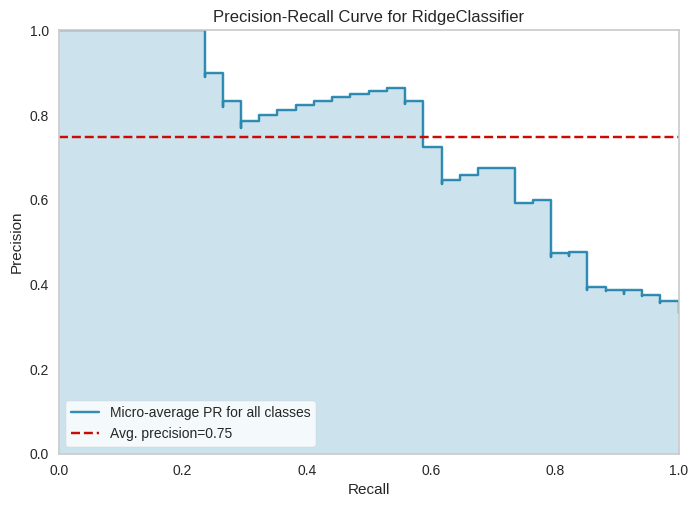

Pr plot for Best Model displayed.


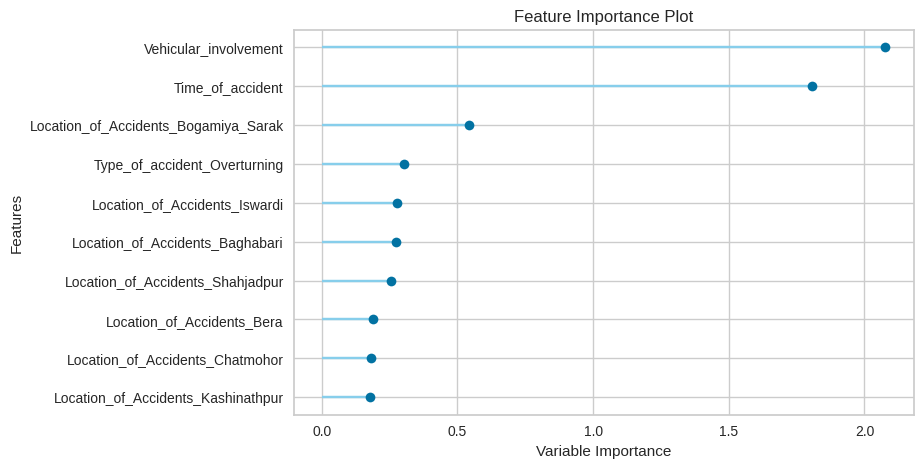

Feature plot for Best Model displayed.


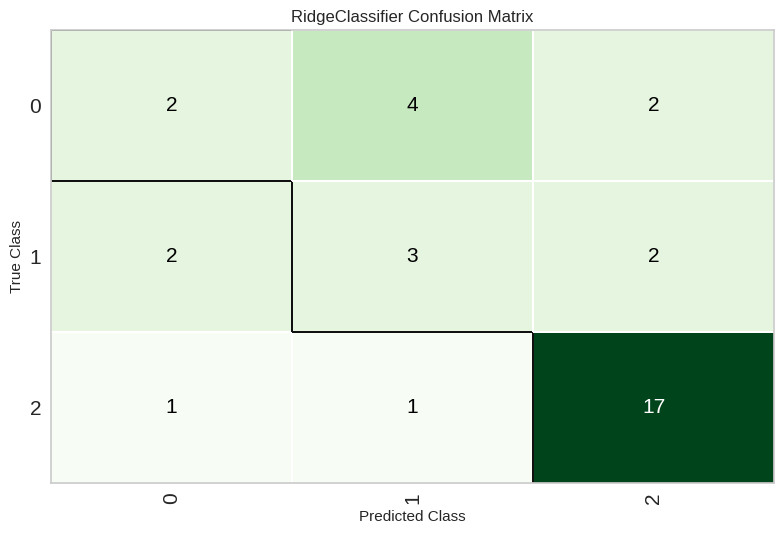

Confusion_matrix plot for Best Model displayed.


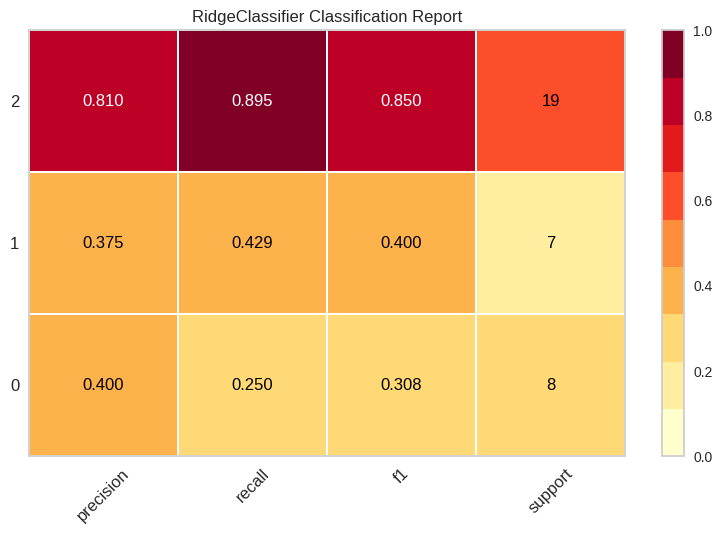

Class_report plot for Best Model displayed.


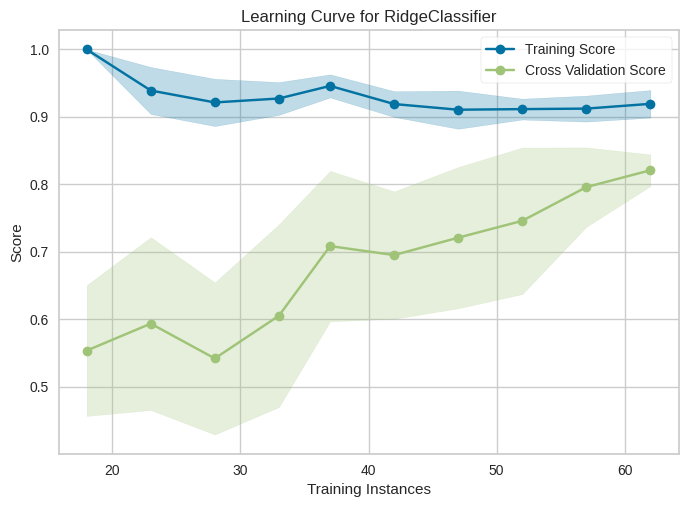

Learning plot for Best Model displayed.
Generating plots for Second Best Model...


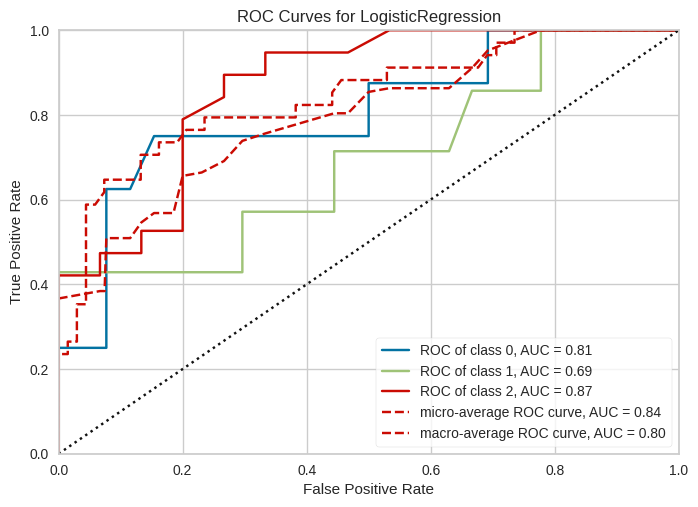

Auc plot for Second Best Model displayed.


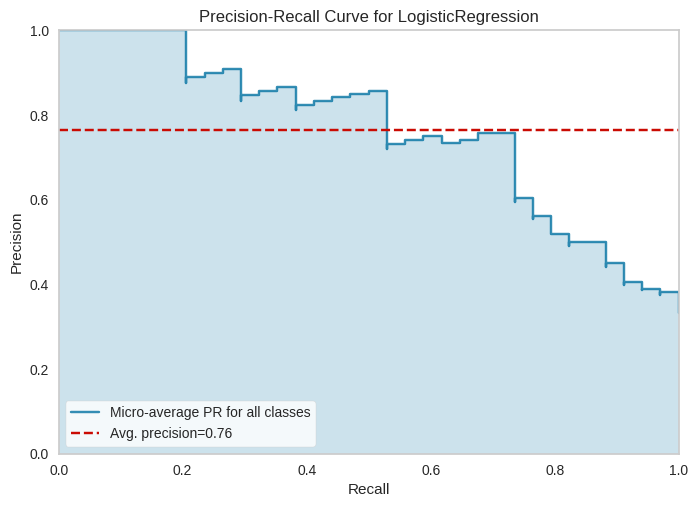

Pr plot for Second Best Model displayed.


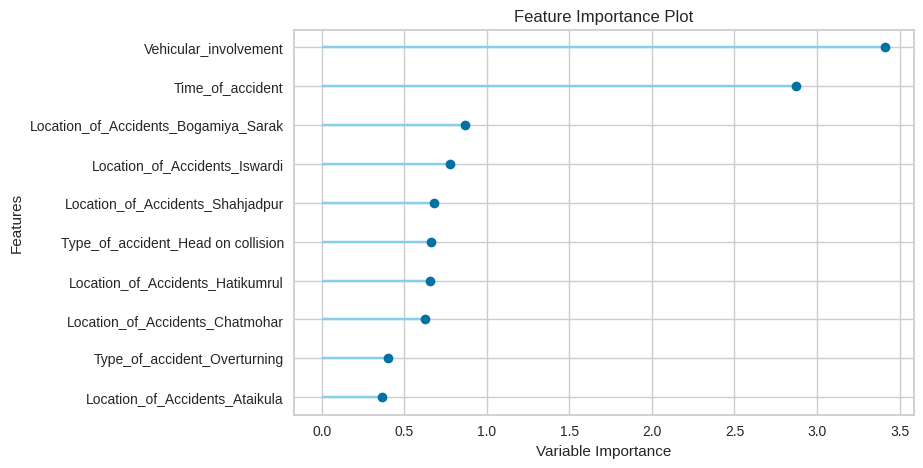

Feature plot for Second Best Model displayed.


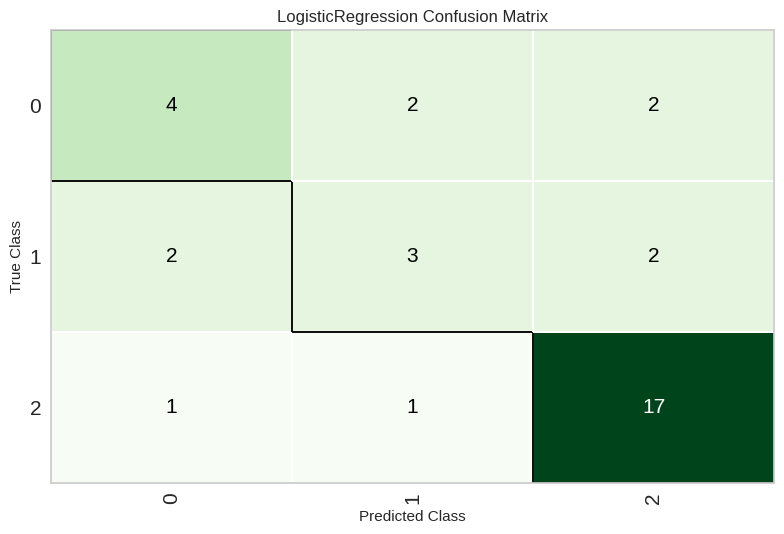

Confusion_matrix plot for Second Best Model displayed.


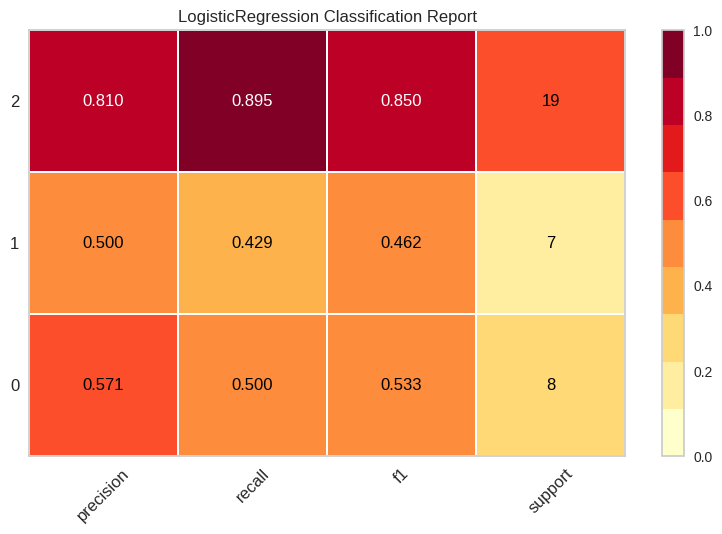

Class_report plot for Second Best Model displayed.


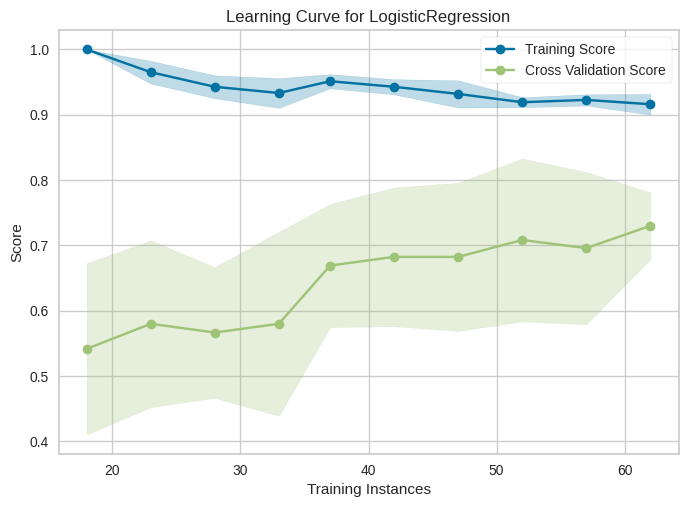

Learning plot for Second Best Model displayed.
Generating plots for XGBoost...


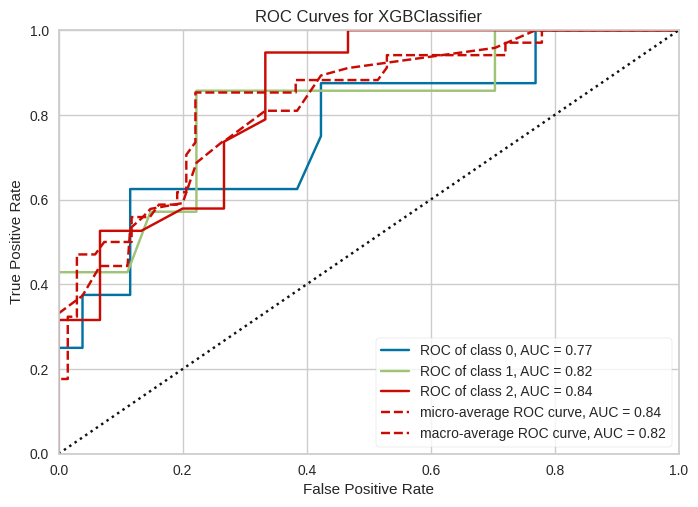

Auc plot for XGBoost displayed.


Plot 'pr' for XGBoost could not be generated: value 0 for Parameter num_class should be greater equal to 1
num_class: Number of output class in the multi-class classification.


<Figure size 800x550 with 0 Axes>

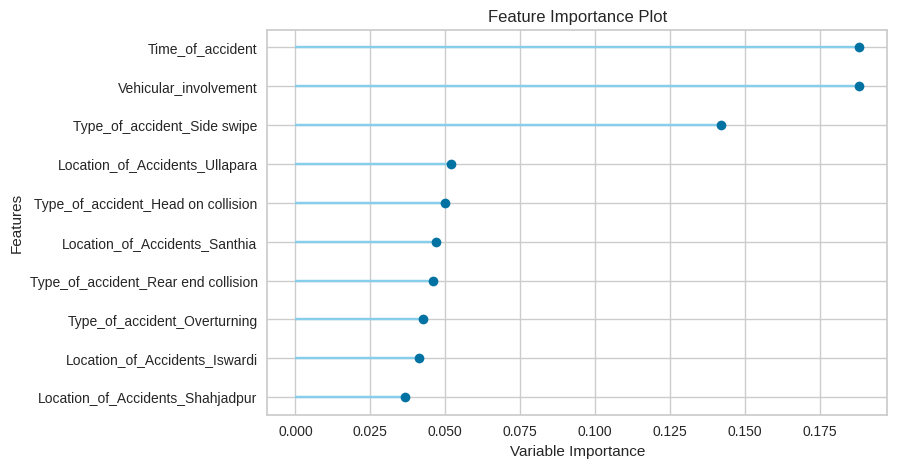

Feature plot for XGBoost displayed.


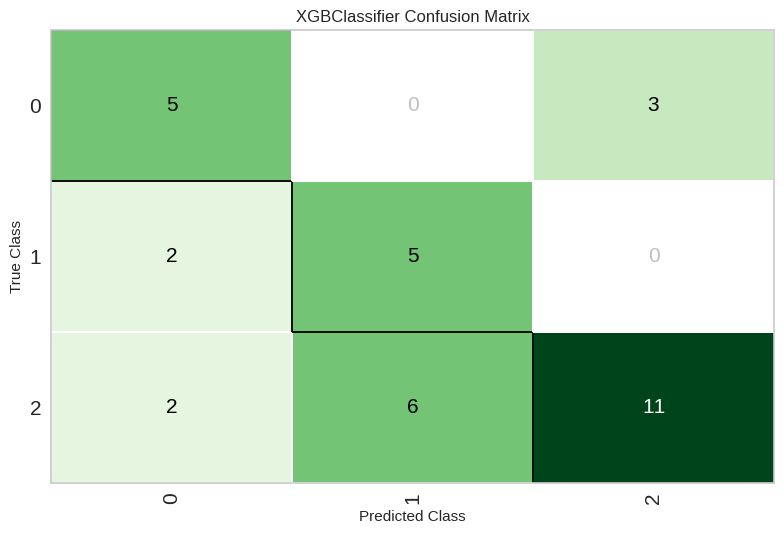

Confusion_matrix plot for XGBoost displayed.


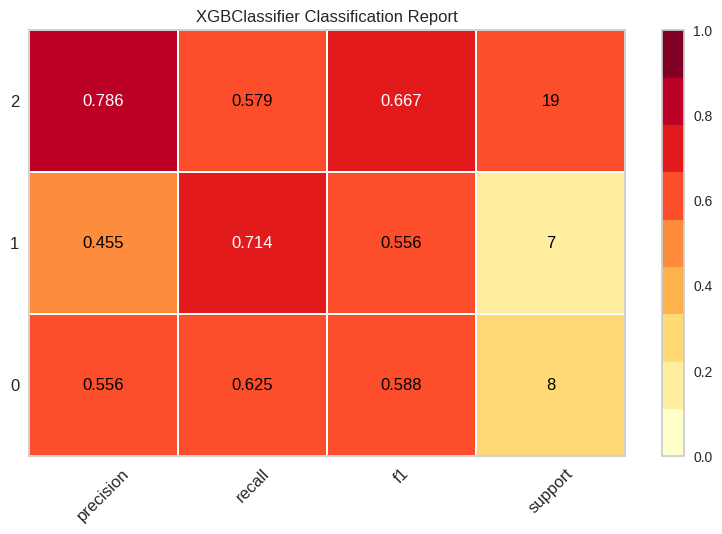

Class_report plot for XGBoost displayed.


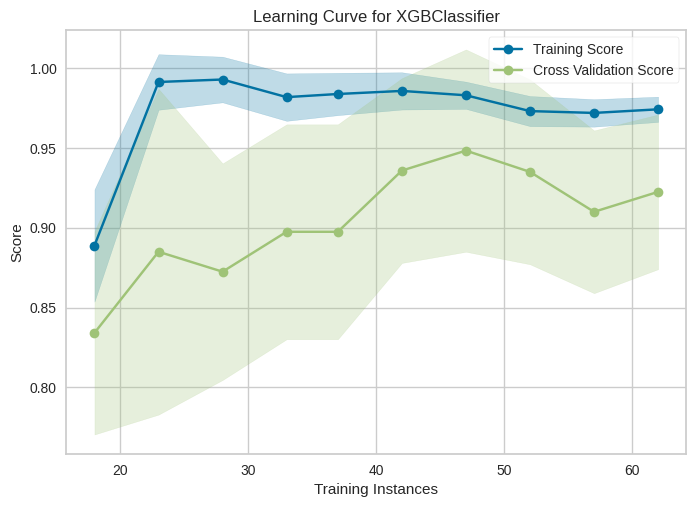

Learning plot for XGBoost displayed.
Generating plots for LightGBM...


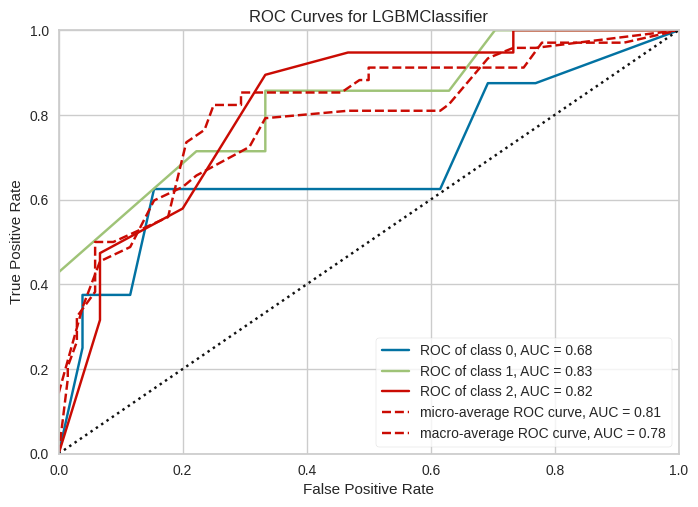

Auc plot for LightGBM displayed.


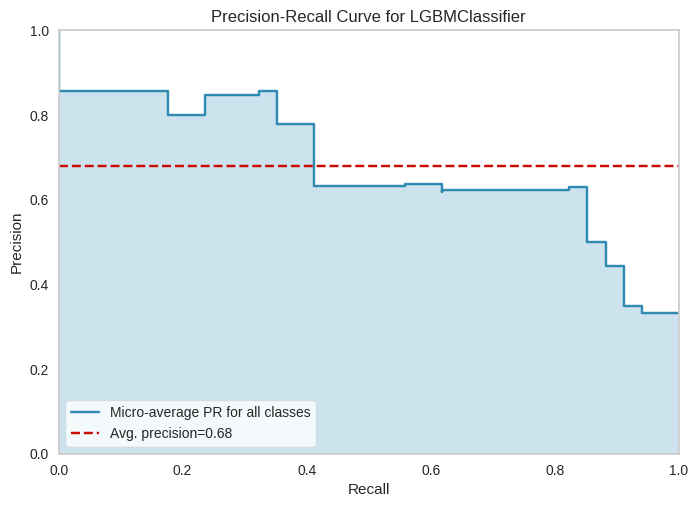

Pr plot for LightGBM displayed.


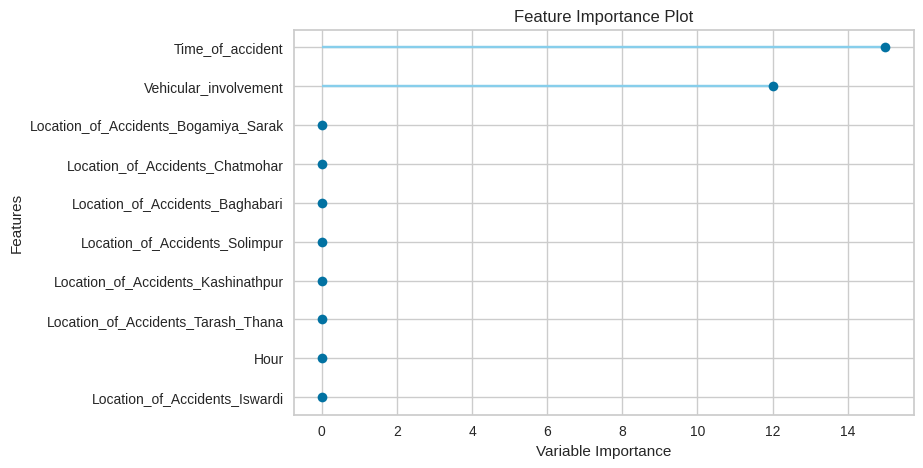

Feature plot for LightGBM displayed.


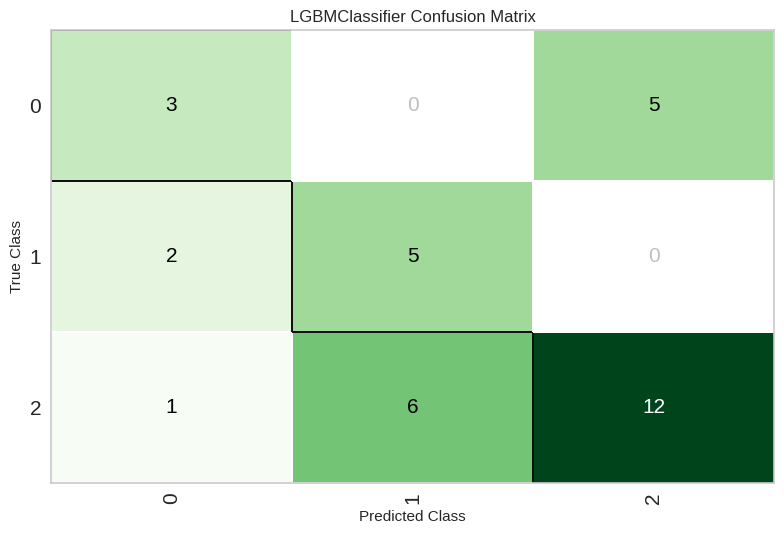

Confusion_matrix plot for LightGBM displayed.


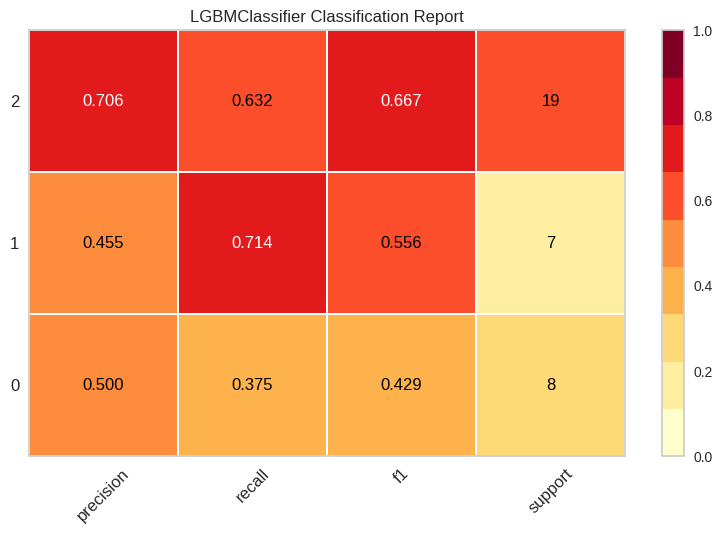

Class_report plot for LightGBM displayed.


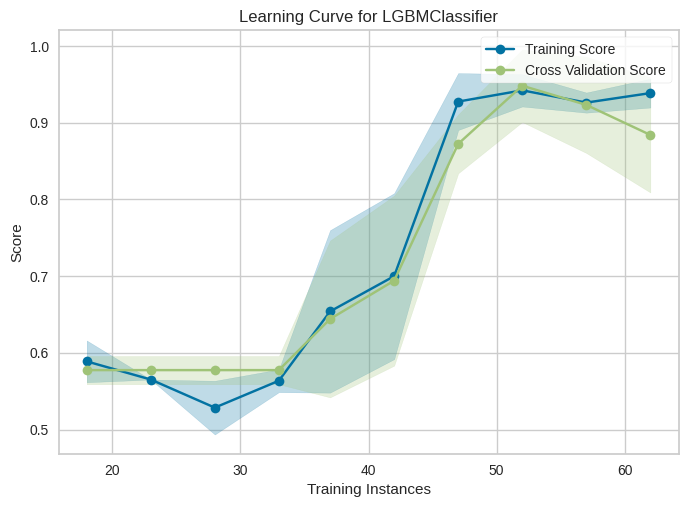

Learning plot for LightGBM displayed.


In [3]:
## import pandas as pd
import matplotlib.pyplot as plt
from pycaret.classification import *
import os

# Load the dataset
file_path = '/kaggle/input/new2yjg/accidents_data.csv'
data = pd.read_csv(file_path, encoding='latin1')

# Data Preprocessing
data.columns = data.columns.str.strip()  # Strip leading and trailing spaces from column names
data.columns = data.columns.str.replace('[^A-Za-z0-9_]', '_', regex=True)  # Replace special characters in column names
data.replace('-', pd.NA, inplace=True)  # Replace placeholder '-' with NaN
data.fillna('Unknown', inplace=True)  # Fill NaN values with 'Unknown'

# Remove classes with less than 2 samples in the target column
if 'Cause_of_accident' in data.columns:
    class_counts = data['Cause_of_accident'].value_counts()
    valid_classes = class_counts[class_counts >= 2].index
    data = data[data['Cause_of_accident'].isin(valid_classes)]
else:
    print("'Cause_of_accident' column not found in the data.")

# Set up PyCaret for classification
clf_setup = setup(
    data=data,
    target='Cause_of_accident',  # Ensure that the sanitized column name is used
    session_id=42,
    fix_imbalance=False,  # Fixing class imbalance
    normalize=False,
    fold=5,  # Using 5 folds for cross-validation
)

# Train and compare models
print("Comparing models...")
best_model = compare_models(sort='Accuracy')  # Choose the best model based on AUC (or any metric)

# Capture the second-best model
second_best_model = compare_models(sort='Accuracy', n_select=2)[1]

# Create the best model explicitly
print(f"Training the best model: {best_model}")
best_model = create_model(best_model)

# Create the second-best model explicitly
print(f"Training the second-best model: {second_best_model}")
second_best_model = create_model(second_best_model)

# Tune the best model to further reduce overfitting and improve accuracy
print(f"Tuning the best model: {best_model}")
best_model = tune_model(best_model)

# Tune the second-best model
print(f"Tuning the second-best model: {second_best_model}")
second_best_model = tune_model(second_best_model)

# xgboost_model = create_model('xgboost')
# lightgbm_model = create_model('lightgbm')

# # Tune the models to improve accuracy
# xgboost_model_tuned = tune_model(xgboost_model)
# lightgbm_model_tuned = tune_model(lightgbm_model)

# List of plot types you want to generate for the models
plot_names = ['auc', 'pr', 'feature', 'confusion_matrix', 'class_report', 'learning']

# Function to generate plots for a given model
def generate_plots(model, model_name):
    print(f"Generating plots for {model_name}...")
    for plot_name in plot_names:
        try:
            plot_model(model, plot=plot_name)  # Just display the plot without saving
            plt.show()  # Display the plot
            print(f"{plot_name.capitalize()} plot for {model_name} displayed.")
        except Exception as e:
            print(f"Plot '{plot_name}' for {model_name} could not be generated: {e}")

# Generate plots for the best model
generate_plots(best_model, "Best Model")

# Generate plots for the second-best model
generate_plots(second_best_model, "Second Best Model")

# # Generate plots for XGBoost
# generate_plots(xgboost_model_tuned, "XGBoost")

# # Generate plots for LightGBM
# generate_plots(lightgbm_model_tuned, "LightGBM")


,Description,Value
0,Session id,42
1,Target,Cause_of_accident
2,Target type,Multiclass
3,Target mapping,"Overspeed: 0, Overtaking: 1, Recklessly Driving: 2"
4,Original data shape,"(112, 9)"
5,Transformed data shape,"(112, 29)"
6,Transformed train set shape,"(78, 29)"
7,Transformed test set shape,"(34, 29)"
8,Numeric features,4
9,Categorical features,4


Comparing models...


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ridge,Ridge Classifier,0.7308,0.0000,0.7308,0.7168,0.6954,0.4915,0.5187,0.0720
lr,Logistic Regression,0.6808,0.0000,0.6808,0.6585,0.6444,0.3841,0.4057,1.2460
lda,Linear Discriminant Analysis,0.6408,0.0000,0.6408,0.6128,0.6020,0.3519,0.3767,0.0680
et,Extra Trees Classifier,0.6300,0.7445,0.6300,0.5711,0.5879,0.3306,0.3533,0.1700
rf,Random Forest Classifier,0.6158,0.7639,0.6158,0.5574,0.5686,0.2904,0.3332,0.1960
qda,Quadratic Discriminant Analysis,0.6158,0.0000,0.6158,0.5186,0.5269,0.1804,0.2643,0.0700
xgboost,Extreme Gradient Boosting,0.6033,0.7352,0.6033,0.5995,0.5735,0.3033,0.3501,0.1100
catboost,CatBoost Classifier,0.5783,0.7441,0.5783,0.5796,0.5512,0.2640,0.3091,0.6180
dummy,Dummy Classifier,0.5775,0.5000,0.5775,0.3338,0.4230,0.0000,0.0000,0.0680
gbc,Gradient Boosting Classifier,0.5650,0.0000,0.5650,0.5691,0.5374,0.2233,0.2728,0.2300


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ridge,Ridge Classifier,0.7308,0.0000,0.7308,0.7168,0.6954,0.4915,0.5187,0.0720
lr,Logistic Regression,0.6808,0.0000,0.6808,0.6585,0.6444,0.3841,0.4057,0.1040
lda,Linear Discriminant Analysis,0.6408,0.0000,0.6408,0.6128,0.6020,0.3519,0.3767,0.0700
et,Extra Trees Classifier,0.6300,0.7445,0.6300,0.5711,0.5879,0.3306,0.3533,0.1640
rf,Random Forest Classifier,0.6158,0.7639,0.6158,0.5574,0.5686,0.2904,0.3332,0.1960
qda,Quadratic Discriminant Analysis,0.6158,0.0000,0.6158,0.5186,0.5269,0.1804,0.2643,0.0780
xgboost,Extreme Gradient Boosting,0.6033,0.7352,0.6033,0.5995,0.5735,0.3033,0.3501,0.0980
catboost,CatBoost Classifier,0.5783,0.7441,0.5783,0.5796,0.5512,0.2640,0.3091,0.5180
dummy,Dummy Classifier,0.5775,0.5000,0.5775,0.3338,0.4230,0.0000,0.0000,0.0720
gbc,Gradient Boosting Classifier,0.5650,0.0000,0.5650,0.5691,0.5374,0.2233,0.2728,0.2320


Training the best model: RidgeClassifier(alpha=1.0, class_weight=None, copy_X=True, fit_intercept=True,
                max_iter=None, positive=False, random_state=42, solver='auto',
                tol=0.0001)


...

Tuning the best model: RidgeClassifier(alpha=1.0, class_weight=None, copy_X=True, fit_intercept=True,
                max_iter=None, positive=False, random_state=42, solver='auto',
                tol=0.0001)


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7500,0.0000,0.7500,0.7250,0.7234,0.5616,0.5741
1,0.7500,0.0000,0.7500,0.8040,0.7134,0.5461,0.5788
2,0.5625,0.0000,0.5625,0.5089,0.4851,0.0894,0.1179
3,0.7333,0.0000,0.7333,0.7500,0.6943,0.4444,0.4905
4,0.8000,0.0000,0.8000,0.8500,0.7743,0.5833,0.6438
Mean,0.7192,0.0000,0.7192,0.7276,0.6781,0.4450,0.4810
Std,0.0815,0.0000,0.0815,0.1176,0.1001,0.1841,0.1880


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).
Tuning the second-best model: LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=42, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7500,0.0000,0.7500,0.7250,0.7234,0.5616,0.5741
1,0.6875,0.0000,0.6875,0.7000,0.6771,0.4737,0.4865
2,0.6250,0.0000,0.6250,0.6184,0.6116,0.3094,0.3179
3,0.6667,0.0000,0.6667,0.5364,0.5943,0.3421,0.3704
4,0.7333,0.0000,0.7333,0.7167,0.7181,0.5238,0.5280
Mean,0.6925,0.0000,0.6925,0.6593,0.6649,0.4421,0.4554
Std,0.0452,0.0000,0.0452,0.0722,0.0533,0.0996,0.0964


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Generating and saving plots for Best_Model...
Plot 'auc' for Best_Model could not be generated: AUC plot not available for estimators with no predict_proba attribute.


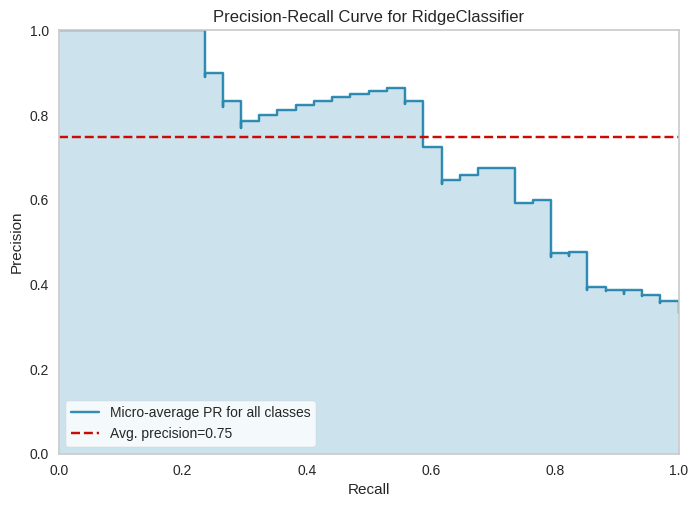

<Figure size 800x550 with 0 Axes>

Saved Pr plot for Best_Model as Best_Model_plots/pr_Best_Model.png.


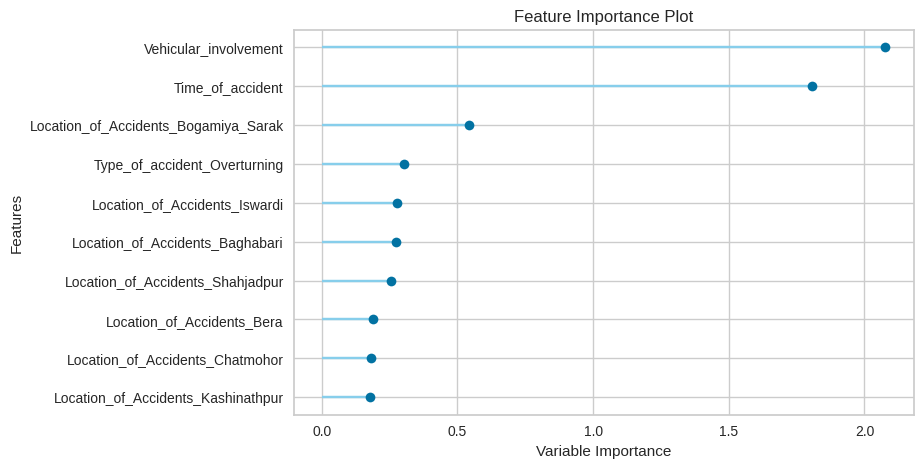

<Figure size 800x550 with 0 Axes>

Saved Feature plot for Best_Model as Best_Model_plots/feature_Best_Model.png.


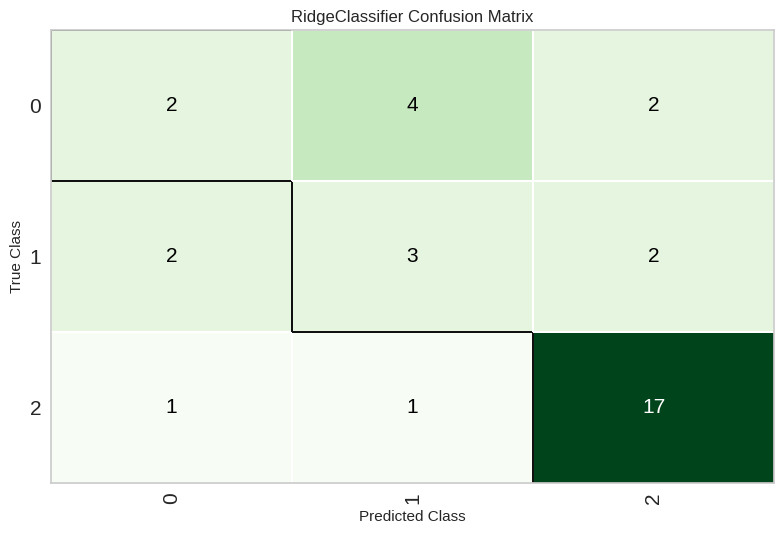

<Figure size 800x550 with 0 Axes>

Saved Confusion_matrix plot for Best_Model as Best_Model_plots/confusion_matrix_Best_Model.png.


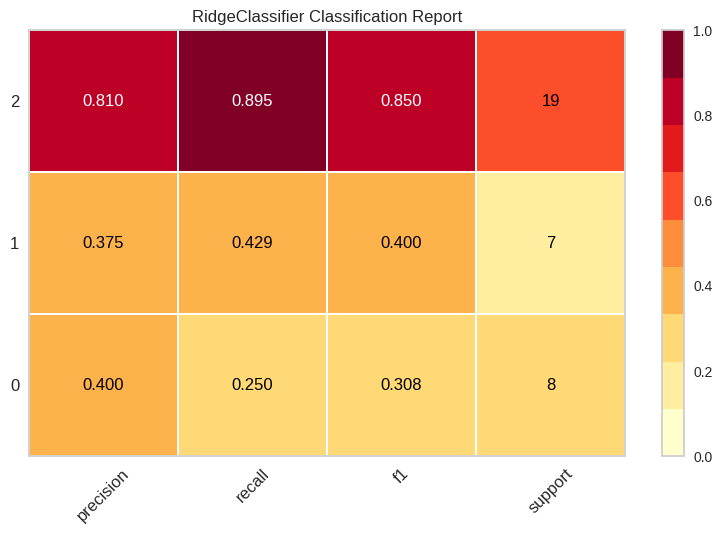

<Figure size 800x550 with 0 Axes>

Saved Class_report plot for Best_Model as Best_Model_plots/class_report_Best_Model.png.


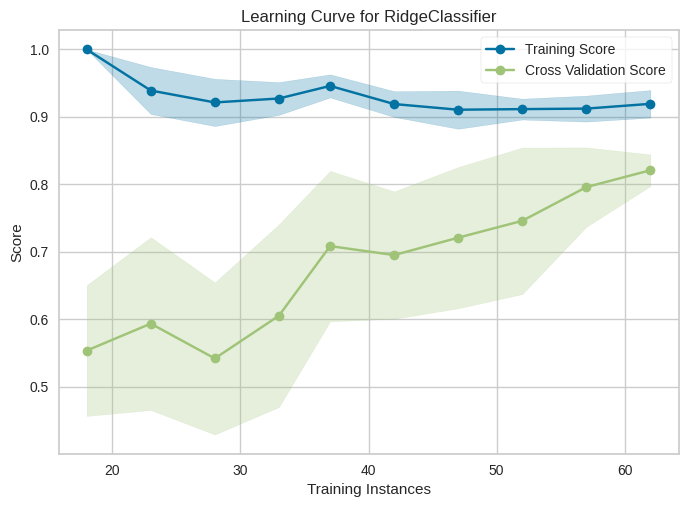

<Figure size 800x550 with 0 Axes>

Saved Learning plot for Best_Model as Best_Model_plots/learning_Best_Model.png.
Generating and saving plots for Second_Best_Model...


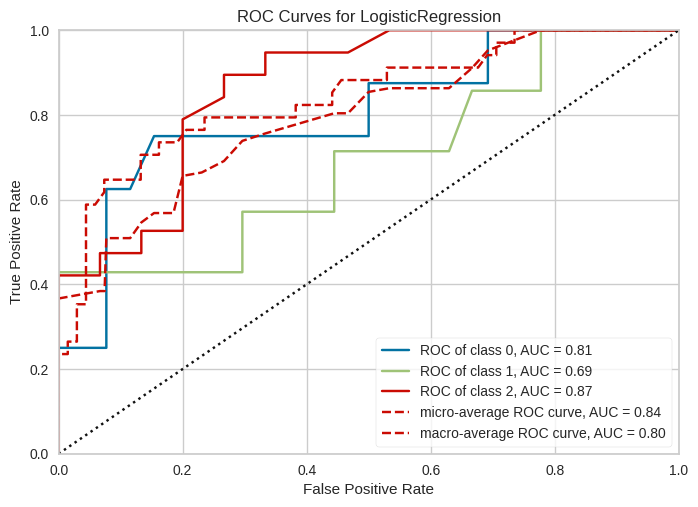

<Figure size 800x550 with 0 Axes>

Saved Auc plot for Second_Best_Model as Second_Best_Model_plots/auc_Second_Best_Model.png.


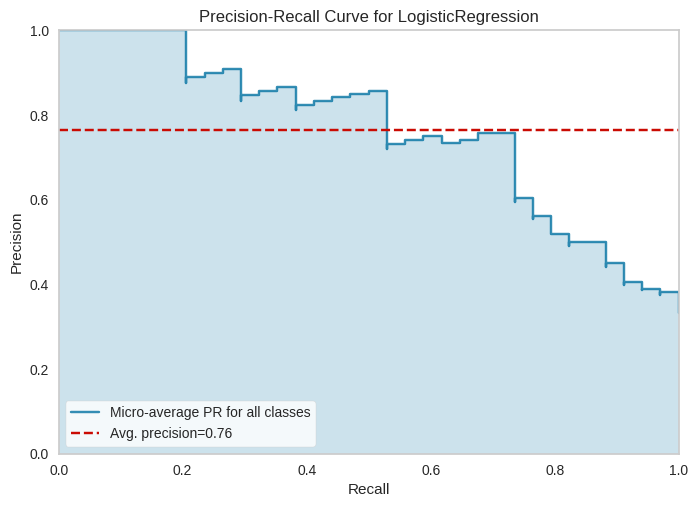

<Figure size 800x550 with 0 Axes>

Saved Pr plot for Second_Best_Model as Second_Best_Model_plots/pr_Second_Best_Model.png.


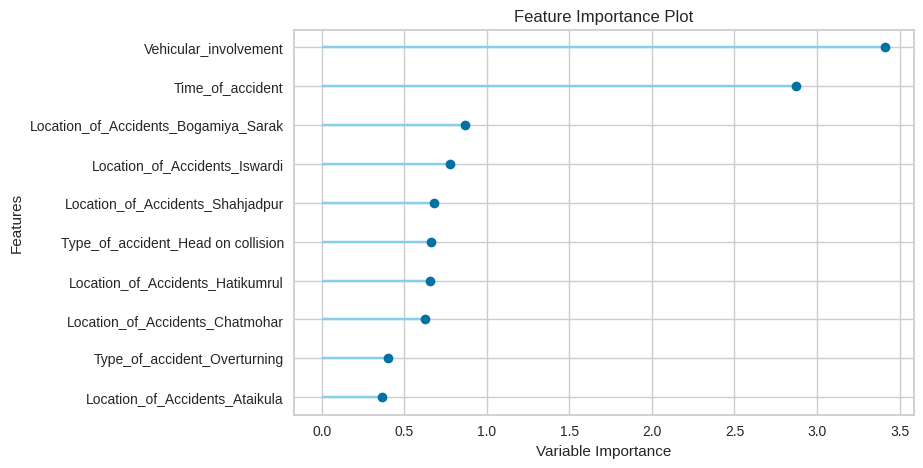

<Figure size 800x550 with 0 Axes>

Saved Feature plot for Second_Best_Model as Second_Best_Model_plots/feature_Second_Best_Model.png.


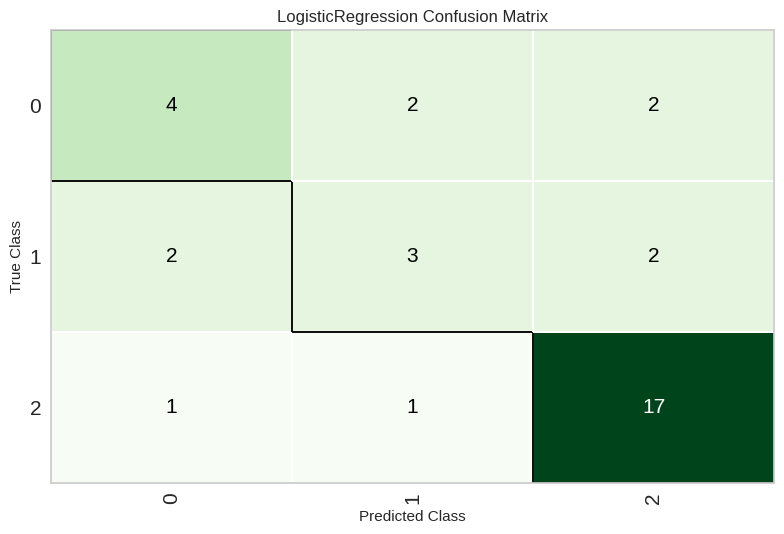

<Figure size 800x550 with 0 Axes>

Saved Confusion_matrix plot for Second_Best_Model as Second_Best_Model_plots/confusion_matrix_Second_Best_Model.png.


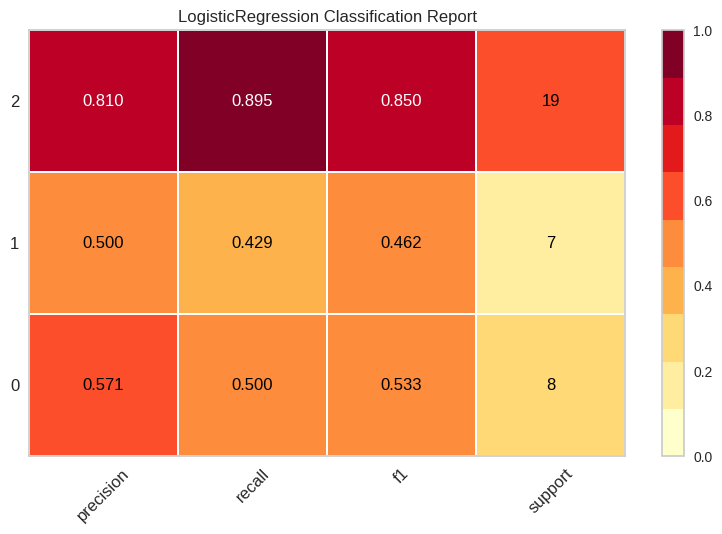

<Figure size 800x550 with 0 Axes>

Saved Class_report plot for Second_Best_Model as Second_Best_Model_plots/class_report_Second_Best_Model.png.


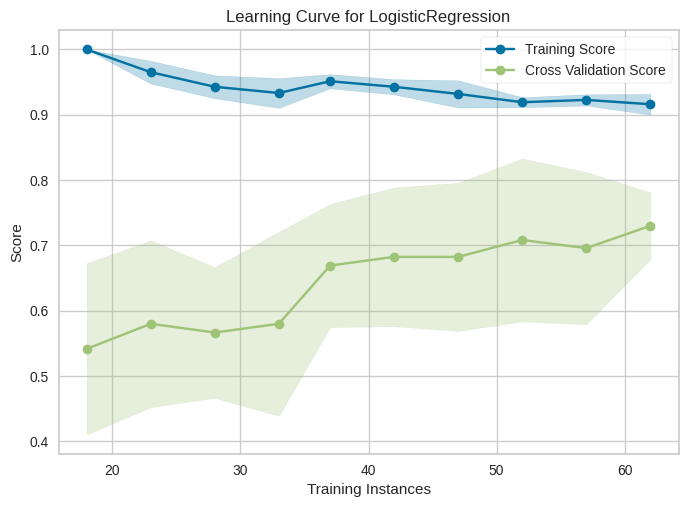

<Figure size 800x550 with 0 Axes>

Saved Learning plot for Second_Best_Model as Second_Best_Model_plots/learning_Second_Best_Model.png.


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from pycaret.classification import *
import os

# Load the dataset
file_path = '/kaggle/input/new2yjg/accidents_data.csv'
data = pd.read_csv(file_path, encoding='latin1')

# Data Preprocessing
data.columns = data.columns.str.strip()  # Strip leading and trailing spaces from column names
data.columns = data.columns.str.replace('[^A-Za-z0-9_]', '_', regex=True)  # Replace special characters in column names
data.replace('-', pd.NA, inplace=True)  # Replace placeholder '-' with NaN
data.fillna('Unknown', inplace=True)  # Fill NaN values with 'Unknown'

# Remove classes with less than 2 samples in the target column
if 'Cause_of_accident' in data.columns:
    class_counts = data['Cause_of_accident'].value_counts()
    valid_classes = class_counts[class_counts >= 2].index
    data = data[data['Cause_of_accident'].isin(valid_classes)]
else:
    print("'Cause_of_accident' column not found in the data.")

# Set up PyCaret for classification
clf_setup = setup(
    data=data,
    target='Cause_of_accident',  # Ensure that the sanitized column name is used
    session_id=42,
    fix_imbalance=False,  # Fixing class imbalance
    normalize=False,
    fold=5,  # Using 5 folds for cross-validation
)

# Train and compare models
print("Comparing models...")
best_model = compare_models(sort='Accuracy')  # Choose the best model based on Accuracy

# Capture the second-best model
second_best_model = compare_models(sort='Accuracy', n_select=2)[1]

# Create the best model explicitly
print(f"Training the best model: {best_model}")
best_model = create_model(best_model)

# Create the second-best model explicitly
print(f"Training the second-best model: {second_best_model}")
second_best_model = create_model(second_best_model)

# Tune the best model to further reduce overfitting and improve accuracy
print(f"Tuning the best model: {best_model}")
best_model = tune_model(best_model)

# Tune the second-best model
print(f"Tuning the second-best model: {second_best_model}")
second_best_model = tune_model(second_best_model)

# List of plot types you want to generate for the models
plot_names = ['auc', 'pr', 'feature', 'confusion_matrix', 'class_report', 'learning']

# Function to generate and save plots for a given model with high resolution
def generate_and_save_plots(model, model_name):
    print(f"Generating and saving plots for {model_name}...")
    
    # Create a directory to save the plots
    output_dir = f"{model_name}_plots"
    os.makedirs(output_dir, exist_ok=True)

    # Loop through the plot types and save each plot with high resolution
    for plot_name in plot_names:
        try:
            plot_model(model, plot=plot_name)  # Generate the plot
            plt.tight_layout()  # Ensure the layout is not cut off
            plot_file = os.path.join(output_dir, f"{plot_name}_{model_name}.png")
            plt.savefig(plot_file, dpi=300)  # Save the plot with high resolution (300 DPI)
            plt.show()  # Ensure the plot is rendered
            plt.close()  # Close the plot to avoid display overlap
            print(f"Saved {plot_name.capitalize()} plot for {model_name} as {plot_file}.")
        except Exception as e:
            print(f"Plot '{plot_name}' for {model_name} could not be generated: {e}")

# Generate and save plots for the best model
generate_and_save_plots(best_model, "Best_Model")

# Generate and save plots for the second-best model
generate_and_save_plots(second_best_model, "Second_Best_Model")

# If you want to do this for other models like XGBoost or LightGBM, you can use the same function call:
# generate_and_save_plots(xgboost_model_tuned, "XGBoost_Model")
# generate_and_save_plots(lightgbm_model_tuned, "LightGBM_Model")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Sample confusion matrix (replace with your own matrix)
cm = np.array([[4, 2, 1],
               [2, 3, 2],
               [1, 1, 18]])

# Plotting the 2D matrix with high DPI
fig, ax = plt.subplots(figsize=(6, 5), dpi=300)  # Increase DPI for higher resolution

# Create the heatmap using matshow
cax = ax.matshow(cm, cmap='Greens')

# Annotating the matrix with the values
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')

# Set labels and title
ax.set_xlabel('Predicted Class')
ax.set_ylabel('True Class')

# Set the ticks on both x and y axes
ax.set_xticks(np.arange(cm.shape[1]))
ax.set_yticks(np.arange(cm.shape[0]))

# Set the tick labels (if needed, modify this to match your classes)
ax.set_xticklabels([0, 1, 2])
ax.set_yticklabels([0, 1, 2])

# Remove gridlines
ax.grid(False)

# Save the plot as PNG
output_path = 'confusion_matrix.png'
fig.savefig(output_path)

output_path
